In [2]:
# !pip install -U --force-reinstall "sympy>=1.13.1" "diffusers" "transformers" "accelerate" "torch==2.14.0" "torchvision==0.29.0"
# Remove the incompatible TorchAudio installation
!pip uninstall -y torchaudio

# Install the packages needed for Stable Diffusion
!pip install -q -U diffusers transformers accelerate safetensors


In [4]:
import sympy
import torch

print("SymPy:", sympy.__version__)
print("PyTorch:", torch.__version__)

from diffusers import StableDiffusionPipeline
print("Diffusers imported successfully!")

SymPy: 1.14.0
PyTorch: 2.11.0+cu128
Diffusers imported successfully!


In [14]:
model_id = "runwayml/stable-diffusion-v1-5"

In [32]:
prompt = """
An ancient futuristic city hidden beneath the ocean,
enormous glowing towers covered with coral,
schools of fish swimming between buildings,
rays of sunlight penetrating the water,
mysterious atmosphere, cinematic lighting,
ultra-detailed fantasy realism
"""

negative_prompt = """
blurry, low quality, distorted,
deformed, extra fingers
"""

In [33]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)


Using device: cuda


In [34]:
pipe = StableDiffusionPipeline.from_pretrained(
    model_id
)

pipe = pipe.to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

In [35]:
generator = torch.Generator(
    device=device
).manual_seed(42)

  0%|          | 0/30 [00:00<?, ?it/s]

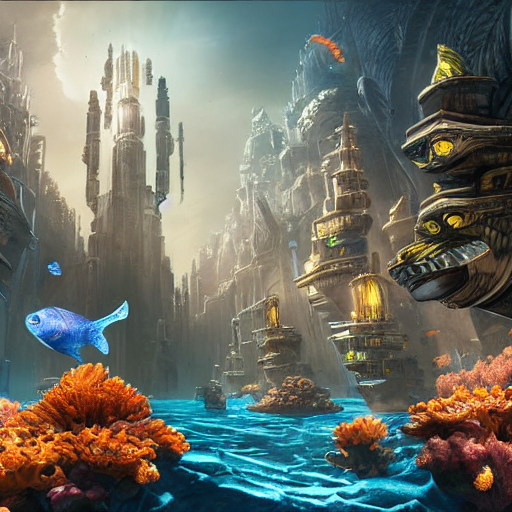

Image saved successfully!


In [36]:
result = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator
)

image = result.images[0]
display(image)


image.save(
    "ai_generated.png"
)

print("Image saved successfully!")

